<a href="https://colab.research.google.com/github/DymaStar/Analysis_Cafe_Sales-/blob/main/DS_110626cafe_eda_workbook_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Робочий зошит: Data Cleaning & EDA
## Датасет: Cafe Sales — Dirty Data for Cleaning Training

> **Ваше завдання:** самостійно заповнити всі клітинки з `# ВАШ КОД ТУТ`.
> Підказки є у кожному розділі — але спробуйте спочатку без них!


---
### Структура проєкту
- **Частина 1** — Первинна інспекція (Tasks 1.1–1.3)
- **Частина 2** — Очищення даних (Tasks 2.1–2.4)
- **Частина 3** — EDA та візуалізація (Tasks 3.1–3.5)
- **Частина 4** — Висновки

---

## ⚙️ Підготовка

Завантажте датасет: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training

Вкажіть шлях до файлу у змінній `FILE_IN` нижче.
Можливі варіанти:
- **Локально:** `FILE_IN = 'data/dirty_cafe_sales.csv'`
- **GitHub Raw URL:** вкажіть посилання на raw-файл
- **Google Colab + Drive:** змонтуйте диск і вкажіть шлях

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker   # Форматування підписів осей графіків
import seaborn as sns                 # Побудова статистичних графіків
import warnings                       # Керування та приховування службових попереджень

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

# ── Вкажіть шлях до вхідного файлу ──────────────────────────
# FILE_IN = 'data/dirty_cafe_sales.csv'   # локальний варіант
FILE_IN = 'https://raw.githubusercontent.com/DymaStar/Analysis_Cafe_Sales-/refs/heads/main/data/dirty_cafe_sales.csv'

# ── Вкажіть шлях для збереження чистого файлу ───────────────
# FILE_OUT = 'data/cafe_sales_clean.csv'  # локальний варіант
FILE_OUT = 'cafe_sales_clean_v2.csv'

print('✓ Готово. Починаємо!')

✓ Готово. Починаємо!


---
# ЧАСТИНА 1 — Первинна інспекція

---

## Task 1.1 — Завантаження та перший огляд

**Що потрібно зробити:**
1. Прочитати CSV файл у датафрейм `df`
2. Зберегти оригінал у `df_original` (на випадок якщо щось піде не так)
3. Вивести перші 10 рядків
4. Викликати `.info()` і `.describe(include='all')`

**Зверніть увагу:** які колонки мають тип `object` замість числових? Чому?

In [111]:

# ==========================================
# Task 1.1 Завантаження датасету
# ==========================================


# Завантаження датасету
df_original = pd.read_csv(FILE_IN)
df = df_original.copy()

print(f'Розмір: {df.shape[0]} рядків × {df.shape[1]} стовпців')  #
# Перші 10 рядків
df.head(10)


Розмір: 10000 рядків × 8 стовпців


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [113]:

# Описова статистика (для числових І текстових колонок)
# Підказка: є параметр include='all'
df.describe(include='all')


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


### ✏️ Спостереження після Task 1.1


### Пояснення показників

- **count** — кількість непропущених (не `NaN`) значень у колонці.
- **unique** — кількість унікальних значень.
- **top** — найчастіше значення (мода) у колонці.
- **freq** — скільки разів зустрічається значення `top`.

### ✏️ Висновок після аналізу описової статистики

Перший огляд показав, що датасет містить **10 000 транзакцій** та поєднує як числові, так і текстові ознаки. У більшості колонок кількість заповнених значень (`count`) менша за 10 000, що свідчить про наявність пропусків.

Колонка **Transaction ID** містить лише унікальні значення і може використовуватися як ідентифікатор запису. Для текстових колонок `unique` показує кількість різних категорій, `top` — найчастіше значення, а `freq` — кількість його повторень. У колонці **Transaction Date** найчастішим значенням є `UNKNOWN`, що свідчить про наявність некоректних даних.

Отримані результати показують, що перед проведенням EDA необхідно виконати очищення даних: обробити пропуски, замінити некоректні значення (`UNKNOWN`, `ERROR` тощо), привести колонки до правильних типів даних та перевірити узгодженість інформації між полями.


## Task 1.2 — Дублікати

**Що потрібно зробити:**
1. Порахувати кількість повних дублікатів
2. Видалити дублікати, зберігши перший зустрічний
3. Вивести кількість рядків до і після

**Підказка:** `df.duplicated()`, `df.drop_duplicates(keep=...)`

In [114]:
# Знайти дублікати
n_dupes = df.duplicated().sum()
print(f'Знайдено дублікатів: {n_dupes}')
print(f'Рядків до видалення: {len(df)}')

# Видалити дублікати
# ВАШ КОД ТУТ

print(f'Рядків після видалення: {len(df)}')

Знайдено дублікатів: 0
Рядків до видалення: 10000
Рядків після видалення: 10000


## Task 1.3 — Аналіз пропущених значень

**Що потрібно зробити:**
1. Замінити значення `'ERROR'`, `'UNKNOWN'`, `''`, `' '` на `np.nan`
2. Порахувати пропуски по кожній колонці (кількість і %)
3. Порахувати загальний % пропусків
4. Побудувати **два** графіки: heatmap і bar chart

**Підказка:** `df.replace(список, np.nan)`, `df.isnull().sum()`

In [115]:
# ==========================================
# Крок 1. Замінюємо "брудні" значення на NaN
# ==========================================

# У датасеті деякі пропущені значення записані не як NaN,
# а як текст ("ERROR", "UNKNOWN"), порожній рядок або пробіл.
# Замінюємо їх на стандартне значення пропуску NumPy (np.nan).

df.replace(
    ['ERROR', 'UNKNOWN', '', ' ', 'error', 'unknown'],
    np.nan,
    inplace=True    # inplace=True — змінює DataFrame безпосередньо, без створення нової копії.
                    # Після виконання всі знайдені значення в df будуть замінені на np.nan.
)

In [116]:


# ==========================================
# Крок 2. Аналіз пропущених значень
# ==========================================

# Рахуємо кількість пропущених значень у кожній колонці
missing_count = df.isna().sum()

# Обчислюємо відсоток пропусків
# (відносно загальної кількості рядків)
missing_pct = (missing_count / len(df) * 100).round(2)

# Формуємо зручну таблицю з результатами
missing_df = pd.DataFrame({
    "Пропусків": missing_count,
    "%": missing_pct
})

# Показуємо лише ті колонки, де є хоча б один пропуск
print(missing_df[missing_df["Пропусків"] > 0])

# ==========================================
# Крок 3. Загальний відсоток пропусків
# ==========================================

# Загальна кількість пропущених значень
total_missing = df.isna().sum().sum()

# Загальна кількість комірок у датасеті
total_cells = df.size

# Загальний відсоток пропусків
total_pct = total_missing / total_cells * 100

print(f"\nЗагальна кількість пропусків: {total_missing}")
print(f"Загальний % пропусків: {total_pct:.2f}%")

                  Пропусків      %
Item                    969   9.69
Quantity                479   4.79
Price Per Unit          533   5.33
Total Spent             502   5.02
Payment Method         3178  31.78
Location               3961  39.61
Transaction Date        460   4.60

Загальна кількість пропусків: 10082
Загальний % пропусків: 12.60%


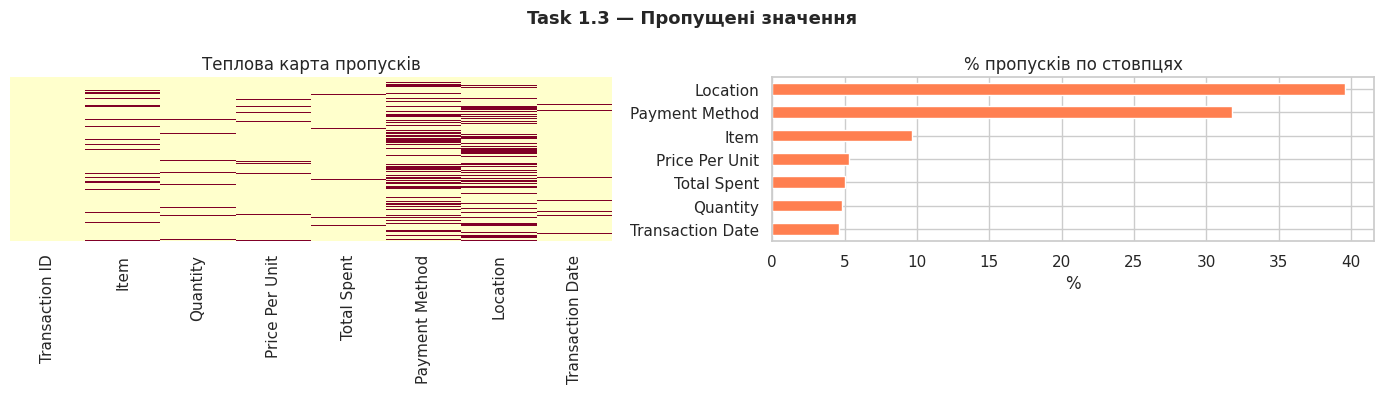

In [117]:
# Крок 4: візуалізація пропусків
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 1.3 — Пропущені значення', fontsize=13, fontweight='bold')

# Графік 1: Heatmap пропусків
# Підказка: sns.heatmap(df.isnull(), cbar=False, ...)
sns.heatmap(
    df.isna(),           # True/False матриця
    cbar=False,          # без шкали кольорів
    cmap='YlOrRd',       # жовтий=є значення, червоний=NaN
    yticklabels=False,   # не показуємо номери рядків (їх занадто багато)
    ax=axes[0]
)
axes[0].set_title('Теплова карта пропусків')

# Графік 2: Horizontal bar chart — % пропусків по колонках
# Підказка: .plot(kind='barh', ax=axes[1], ...)
missing_df[missing_df['Пропусків'] > 0]['%'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('% пропусків по стовпцях')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

---
# ЧАСТИНА 2 — Очищення даних

---

## Підготовка: перейменування колонок

Перейменуйте колонки: приберіть пробіли і зробіть назви у форматі `snake_case`.

| Стара назва | Нова назва |
|-------------|------------|
| `Transaction ID` | `transaction_id` |
| `Item` | `item` |
| `Quantity` | `quantity` |
| `Price Per Unit` | `price_per_unit` |
| `Total Spent` | `total_spent` |
| `Payment Method` | `payment_method` |
| `Location` | `location` |
| `Transaction Date` | `transaction_date` |

In [118]:
# ==========================================
# Крок 1. Очищення назв колонок
# ==========================================

# Видаляємо зайві пробіли на початку та в кінці назв колонок
df.columns = df.columns.str.strip()

# ==========================================
# Крок 2. Перейменування колонок
# ==========================================

# Переводимо назви колонок у зручний формат snake_case
df = df.rename(columns={
    'Transaction ID'  : 'transaction_id',
    'Item'            : 'item',
    'Quantity'        : 'quantity',
    'Price Per Unit'  : 'price_per_unit',
    'Total Spent'     : 'total_spent',
    'Payment Method'  : 'payment_method',
    'Location'        : 'location',
    'Transaction Date': 'transaction_date',
})


# Перевіряємо результат
print("Нові назви колонок:")
print(df.columns.tolist())

Нові назви колонок:
['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


## Task 2.1 — Обробка пропусків у категорійних колонках

**Стратегії:**

| Колонка | Стратегія |
|---------|----------|
| `transaction_id` | Видалити рядок |
| `item` | По ціні зі словника (якщо є price) → інакше мода |
| `payment_method` | `'Unknown'` — рекомендовано; або мода (варіант Б) |
| `location` | `'Unknown'` — рекомендовано; або мода (варіант Б) |

**Підказки:**
- `df.dropna(subset=[...])` — видалити рядки де NaN у вказаних колонках
- `df['col'].fillna('Unknown')` — заповнити рядком
- Словник і мода для item — виконуються у Task 2.2 після конвертації числових типів

In [119]:
# ==========================================
# Task 2.2. Конвертація типів даних
# ==========================================

# transaction_id: видалити рядки де NaN
before = len(df)
df.dropna(subset=['transaction_id'], inplace=True)
print(f'Видалено рядків без transaction_id: {before - len(df)}')

# payment_method:
# Варіант А (рекомендований) — заповнити 'Unknown'
# df.payment_method.fillna('Unknown', inplace=True)

# Варіант Б — заповнити модою (розкоментуйте)
# mode_pay = df['payment_method'].mode()[0]
# df['payment_method'].fillna(mode_pay, inplace=True)

# location:
# Варіант А (рекомендований) — заповнити 'Unknown'
# df.location.fillna('Unknown', inplace=True)

# Варіант Б — заповнити модою (розкоментуйте)
# mode_loc = df['location'].mode()[0]
# df['location'].fillna(mode_loc, inplace=True)

# Замінюємо всі пропущені значення (NaN) у колонці на рядок "Unknown"
df.fillna({'payment_method': 'Unknown', 'location': 'Unknown'}, inplace=True)

display(df[['payment_method', 'location']].isna().sum())


# item: заповнюємо у Task 2.2 після конвертації числових типів
mode_item = df['item'].mode()[0]  # зберігаємо заздалегідь
print(f'Зберегли mode_item = "{mode_item}" для резервного заповнення')

Видалено рядків без transaction_id: 0


,0
payment_method,0
location,0


Зберегли mode_item = "Juice" для резервного заповнення


### варіант2

In [120]:
# transaction_id: видалити рядки, де відсутній ідентифікатор транзакції
before = len(df)
df = df.dropna(subset=['transaction_id']).copy()
print(f'Видалено рядків без transaction_id: {before - len(df)}')

# payment_method: пропуски заповнюємо окремою категорією Unknown
# Це краще, ніж мода, бо відсутній спосіб оплати теж є інформацією.
df['payment_method'] = df['payment_method'].fillna('Unknown')

# location: пропуски також заповнюємо Unknown
df['location'] = df['location'].fillna('Unknown')

# item поки не заповнюємо, бо далі будемо відновлювати його логічно через price_per_unit.
print('Пропуски після обробки payment_method/location:')
display(df[['transaction_id', 'payment_method', 'location', 'item']].isna().sum())


Видалено рядків без transaction_id: 0
Пропуски після обробки payment_method/location:


,0
transaction_id,0
payment_method,0
location,0
item,969


## Task 2.2 — Конвертація типів і заповнення item / price / quantity

**Порядок дій:**
1. Конвертувати числові типи (`errors='coerce'`)
2. Побудувати словник `ITEM_PRICE` кодом: `item → мода ціни` з даних
3. **Ситуація 1:** item = NaN, price є → знайти item зі зворотного словника
4. **Ситуація 2:** item є, price = NaN → знайти price зі словника
5. **Ситуація 3:** обидва NaN → item = мода, price = по item
6. **quantity:** якщо є price і total → `qty = total / price`; інакше медіана по товару
7. Відновити `total_spent = qty × price`, перевірити збіг

**Підказки:**
```python
# Побудова словника з даних
df.groupby('item')['price_per_unit'].agg(lambda x: x.mode()[0]).to_dict()
# Зворотний словник
{round(v,2): k for k, v in ITEM_PRICE.items()}
# Медіана по групі
df.groupby('item')['quantity'].transform('median')
```

In [121]:
# Конвертація числових колонок (errors='coerce' → некоректне стає NaN)
# ==========================================
# Task 2.2. Конвертація типів даних
# ==========================================

# Перетворюємо числові колонки з типу object у numeric.
# Некоректні текстові значення (наприклад "ERROR")
# автоматично замінюються на NaN.

df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['price_per_unit'] = pd.to_numeric(df['price_per_unit'], errors='coerce')
df['total_spent'] = pd.to_numeric(df['total_spent'], errors='coerce')

# Перетворюємо колонку з датою у формат datetime.
# Некоректні значення будуть замінені на NaT
# (Not a Time - аналог NaN для дат).

df['transaction_date'] = pd.to_datetime(
    df['transaction_date'],
    errors='coerce'
)

# ==========================================
# Перевіряємо результат конвертації
# ==========================================

print("Типи даних після конвертації:")
print(df.dtypes)

Типи даних після конвертації:
transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
dtype: object


In [122]:
# ==========================================
# Аналіз цін для кожного товару
# ==========================================

# Обчислюємо медіанну ціну кожного товару.
# Медіана менш чутлива до викидів, ніж середнє значення,
# тому її зручно використовувати для відновлення пропусків.

price_by_item = df.groupby('item')['price_per_unit'].median()

print("Медіанна ціна для кожного товару:")
display(price_by_item)

Медіанна ціна для кожного товару:


,price_per_unit
item,
Cake,3.0
Coffee,2.0
Cookie,1.0
Juice,3.0
Salad,5.0
Sandwich,4.0
Smoothie,4.0
Tea,1.5


In [123]:
# ==========================================================
# Приклад 2.
# Для кожного товару шукаємо найчастішу ціну
# ==========================================================

df.groupby('item')['price_per_unit'] \
    .agg(lambda x: x.mode().tolist()) \
    .to_dict()

{'Cake': [3.0],
 'Coffee': [2.0],
 'Cookie': [1.0],
 'Juice': [3.0],
 'Salad': [5.0],
 'Sandwich': [4.0],
 'Smoothie': [4.0],
 'Tea': [1.5]}

In [124]:

# ==========================================================
# ПРИКЛАД.
# Те саме, що й попередній приклад, але mode()
# перетворюється не у список (list), а у кортеж (tuple).
#
# Це лише демонстрація.
# У цьому проекті надалі використовується tolist().
# ==========================================================

df.groupby('item')['price_per_unit'] \
    .agg(lambda x: tuple(x.mode())) \
    .to_dict()

{'Cake': (3.0,),
 'Coffee': (2.0,),
 'Cookie': (1.0,),
 'Juice': (3.0,),
 'Salad': (5.0,),
 'Sandwich': (4.0,),
 'Smoothie': (4.0,),
 'Tea': (1.5,)}

In [125]:
# ==========================================================
# Приклад 4.
# Якщо однаково популярних цін декілька,
# можна випадково вибрати одну.
# ==========================================================

np.random.default_rng(42)

ex = {
    'Cake': (3.0, 1.0),
    'Coffee': (2.0,),
    'Cookie': (1.0,),
    'Juice': (3.0,),
    'Salad': (5.0,),
    'Sandwich': (4.0,),
    'Smoothie': (4.0,),
    'Tea': (1.5,)
}

price_cake = np.random.choice(ex['Cake'])

price_cake

np.float64(1.0)

In [126]:
# ==========================================================
# Приклад 1.
# mode() може повертати декілька значень
# ==========================================================

ex = pd.DataFrame({
    "name": ['c1','c1','c1','c1','c1','c1','c1','c1'],
    "score": [1,1,1,1,3,3,3,3]
})

ex.groupby("name")["score"].agg(lambda x: x.mode().tolist())

,score
name,
c1,"[1, 3]"


In [127]:
# ==========================================
# Приклад. Інвертуємо словник
# ==========================================

# Початковий словник:
# ключ   -> товар
# значення -> список можливих цін

np.random.default_rng(42)

ex = {
    'Cake': [3.0, 1.0],
    'Coffee': [2.0],
    'Cookie': [1.0],
    'Juice': [3.0],
    'Salad': [5.0],
    'Sandwich': [4.0],
    'Smoothie': [4.0],
    'Tea': [1.5]
}

# Створюємо порожній словник
s = {}

# Проходимо по всіх товарах
for key, value in ex.items():

    # Якщо товар має декілька можливих цін,
    # перебираємо кожну окремо
    for el in value:

        # Для кожної ціни додаємо товар у словник
        s.setdefault(el, []).append(key)

# Переглядаємо результат
print(s)

{3.0: ['Cake', 'Juice'], 1.0: ['Cake', 'Cookie'], 2.0: ['Coffee'], 5.0: ['Salad'], 4.0: ['Sandwich', 'Smoothie'], 1.5: ['Tea']}


In [128]:
# Крок 0: будуємо словник ITEM_PRICE з даних (item → мода ціни)
# ==========================================
# Крок 0. Створення словника ITEM_PRICE
# ==========================================

# Видаляємо рядки, у яких одночасно відсутня
# назва товару або його ціна.
# Це потрібно, щоб функція mode() не працювала
# з порожніми значеннями.

ITEM_PRICE = (
    df
    .dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .agg(lambda x: x.mode().tolist())
    .to_dict()
)

# ==========================================
# Підказка (спрощений варіант)
# ==========================================

# df.dropna(subset=['item', 'price_per_unit']) \
#   .groupby('item')['price_per_unit'] \
#   .agg(lambda x: x.mode()[0]) \
#   .to_dict()


# ==========================================
# Створення зворотного словника
# ціна → список товарів
# ==========================================

PRICE_ITEM = {}

for key, value in ITEM_PRICE.items():
    for el in value:
        PRICE_ITEM.setdefault(el, []).append(key)

# ==========================================
# Перевірка результату
# ==========================================

print(f"Словник побудовано: {len(ITEM_PRICE)} товарів")

print("\n---ITEM_PRICE---")
print(pd.Series(ITEM_PRICE).sort_index())

print("\n---PRICE_ITEM---")
print(pd.Series(PRICE_ITEM).sort_index())

Словник побудовано: 8 товарів

---ITEM_PRICE---
Cake        [3.0]
Coffee      [2.0]
Cookie      [1.0]
Juice       [3.0]
Salad       [5.0]
Sandwich    [4.0]
Smoothie    [4.0]
Tea         [1.5]
dtype: object

---PRICE_ITEM---
1.0                [Cookie]
1.5                   [Tea]
2.0                [Coffee]
3.0           [Cake, Juice]
4.0    [Sandwich, Smoothie]
5.0                 [Salad]
dtype: object


In [129]:
df.describe(include='all')

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
count,10000,9031,9521.000000,9467.000000,9498.000000,10000,10000,9540
unique,10000,8,NaN,NaN,NaN,4,3,NaN
top,TXN_9226047,Juice,NaN,NaN,NaN,Unknown,Unknown,NaN
freq,1,1171,NaN,NaN,NaN,3178,3961,NaN
mean,NaN,NaN,3.028463,2.949984,8.924352,NaN,NaN,2023-07-01 23:00:31.698113280
min,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,2023-01-01 00:00:00
25%,NaN,NaN,2.000000,2.000000,4.000000,NaN,NaN,2023-04-01 00:00:00
50%,NaN,NaN,3.000000,3.000000,8.000000,NaN,NaN,2023-07-02 00:00:00
75%,NaN,NaN,4.000000,4.000000,12.000000,NaN,NaN,2023-10-02 00:00:00
max,NaN,NaN,5.000000,5.000000,25.000000,NaN,NaN,2023-12-31 00:00:00


In [130]:

# Показати всі унікальні значення у стовпці price_per_unit
# Використовується для швидкої перевірки можливих цін і наявності пропусків.
df['price_per_unit'].unique()

array([2. , 3. , 1. , 5. , 4. , 1.5, nan])

In [131]:
# ==========================================
# Ситуація 1.
# Якщо назва товару (item) відсутня,
# але відома його ціна (price_per_unit),
# намагаємося відновити назву товару.
# ==========================================

# Для відтворюваності результатів
# фіксуємо генератор випадкових чисел.
np.random.default_rng(42)

# Створюємо маску:
# item = NaN, але price_per_unit має значення.
mask1 = df.item.isna() & df.price_per_unit.notna()

# Для кожної ціни знаходимо можливий товар.
# Якщо одній ціні відповідає декілька товарів,
# випадково вибираємо один із них.
df.loc[mask1, 'item'] = (
    df.loc[mask1, 'price_per_unit']
      .round(2)   # округлюємо ціну до 2 знаків
      .map(
          lambda price:
              np.random.choice(PRICE_ITEM[price])
              if price in PRICE_ITEM
              else None
      )
)

# ==========================================
# Перевірка
# ==========================================

# Виводимо кількість рядків,
# у яких було відновлено item за ціною.
print(f"Ситуація 1 (є price → item): {mask1.sum()} рядків")

Ситуація 1 (є price → item): 915 рядків


In [132]:

# ==========================================
# Ситуація 2.
# Якщо товар відомий, але ціна відсутня,
# відновлюємо ціну за назвою товару.
# ==========================================

# Створюємо маску:
# item є, але price_per_unit = NaN.
mask2 = df.item.notna() & df.price_per_unit.isna()

# Для кожного товару знаходимо його типову ціну.
# Якщо товар має кілька можливих модальних цін,
# випадково вибираємо одну.
df.loc[mask2, 'price_per_unit'] = (
    df.loc[mask2, 'item']
      .map(
          lambda it:
              np.random.choice(ITEM_PRICE[it])
              if it in ITEM_PRICE
              else None
      )
)    # Для кожної ціни знайти можливий товар.
# Якщо одній ціні відповідає кілька товарів,
# випадково вибрати один із них.
# Якщо ціна відсутня у словнику — повернути None.

# ==========================================
# Перевірка
# ==========================================

print(f"Ситуація 2 (є item → price): {mask2.sum()} рядків")

Ситуація 2 (є item → price): 479 рядків


In [133]:
# ==========================================
# Перевірка залишкових пропусків
# ==========================================

# Перевіряємо, скільки рядків, де одночасно
# відсутні товар (item), ціна (price_per_unit)
# та загальна сума покупки (total_spent).

missing_item_price_total = (
    df.item.isna() &
    df.price_per_unit.isna() &
    df.total_spent.isna()
).sum()

print(f"Item + Price + Total Spent = {missing_item_price_total}")


# ==========================================
# Перевіряємо, скільки рядків, де одночасно
# відсутні товар (item), ціна (price_per_unit)
# та кількість (quantity).
# ==========================================

missing_item_price_qty = (
    df.item.isna() &
    df.price_per_unit.isna() &
    df.quantity.isna()
).sum()

print(f"Item + Price + Quantity = {missing_item_price_qty}")


# ==========================================
# Перевіряємо повністю порожні записи.
# Одночасно відсутні:
# - товар
# - ціна
# - кількість
# - загальна сума
# ==========================================

missing_all = (
    df.item.isna() &
    df.price_per_unit.isna() &
    df.quantity.isna() &
    df.total_spent.isna()
).sum()

print(f"Item + Price + Quantity + Total = {missing_all}")

Item + Price + Total Spent = 3
Item + Price + Quantity = 3
Item + Price + Quantity + Total = 0


# ============================================================
### Аналіз комбінацій пропущених значень
# ============================================================
### Перевіряємо, які поля одночасно відсутні в одному рядку.
### Це допомагає визначити, чи можна відновити пропущені дані
### за допомогою інших колонок.

In [134]:
# Скільки рядків, де одночасно відсутні назва товару та його ціна
(df.item.isna() & df.price_per_unit.isna()).sum()

np.int64(54)

In [135]:
# Скільки рядків, де одночасно відсутні:
# товар + ціна + загальна сума покупки
(df.item.isna() &
 df.price_per_unit.isna() &
 df.total_spent.isna()).sum()

np.int64(3)

In [136]:
# Скільки рядків, де одночасно відсутні:
# товар + ціна + кількість
(df.item.isna() &
 df.price_per_unit.isna() &
 df.quantity.isna()).sum()

np.int64(3)

In [137]:
# Перевіряємо, чи існують повністю "порожні" покупки:
# товар + ціна + кількість + загальна сума відсутні одночасно
(df.item.isna() &
 df.price_per_unit.isna() &
 df.quantity.isna() &
 df.total_spent.isna()).sum()


np.int64(0)

In [138]:


# Ситуація 3: обидва NaN → item = мода, price = по item
mask3 = df['item'].isna() & df['price_per_unit'].isna()

# Найчастіший товар у датасеті
mode_item = df['item'].mode()[0]   # рахуємо після заповнення ситуацій 1 і 2

# Типова ціна для цього товару.
# ITEM_PRICE[mode_item] може бути списком, тому беремо перший елемент.
mode_price = ITEM_PRICE.get(mode_item)[0]

df.loc[mask3, 'item']           = mode_item
df.loc[mask3, 'price_per_unit'] = mode_price #   (ITEM_PRICE.get(mode_item))
print(f'Ситуація 3 (обидва NaN → мода "{mode_item}"): {mask3.sum()} рядків')

print(f'\nNaN у item:           {df["item"].isna().sum()}')
print(f'NaN у price_per_unit: {df["price_per_unit"].isna().sum()}')

Ситуація 3 (обидва NaN → мода "Coffee"): 54 рядків

NaN у item:           0
NaN у price_per_unit: 0


In [139]:
# Заповнення quantity

# Варіант А: якщо quantity відсутня, але є total_spent і price_per_unit,
# кількість можна відновити за формулою: quantity = total_spent / price_per_unit.
mask_qty = (
    df['quantity'].isna() &
    df['price_per_unit'].notna() &
    df['total_spent'].notna()
)

df.loc[mask_qty, 'quantity'] = (
    df.loc[mask_qty, 'total_spent'] / df.loc[mask_qty, 'price_per_unit']
).round()

print(f'quantity відновлено через total/price: {mask_qty.sum()} рядків')

# Варіант Б: якщо після цього quantity все ще має пропуски,
# заповнюємо їх медіанною кількістю для відповідного товару.
qty_median = df.groupby('item')['quantity'].transform('median')
df['quantity'] = df['quantity'].fillna(qty_median)

# Якщо ще залишилися пропуски, заповнюємо загальною медіаною.
df['quantity'] = df['quantity'].fillna(df['quantity'].median())

# Кількість має бути цілим числом
df['quantity'] = df['quantity'].round().astype('Int64')

print(f'quantity після заповнення: {df["quantity"].isna().sum()} NaN залишилось')


quantity відновлено через total/price: 459 рядків
quantity після заповнення: 0 NaN залишилось


In [140]:
# Відновлення total_spent там, де він відсутній
# Формула: total_spent = quantity × price_per_unit

mask_total = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_total, 'total_spent'] = (
    df.loc[mask_total, 'quantity'].astype(float) * df.loc[mask_total, 'price_per_unit']
).round(2)

print(f'total_spent відновлено (був NaN): {mask_total.sum()} рядків')

# Залишкові NaN у total_spent заповнюємо медіаною
# Це резервний варіант для рядків, де не вистачає даних для формули.
df['total_spent'] = df['total_spent'].fillna(df['total_spent'].median())

print(f'NaN у total_spent після заповнення: {df["total_spent"].isna().sum()}')


total_spent відновлено (був NaN): 502 рядків
NaN у total_spent після заповнення: 0


In [141]:
# =====================================================
# Альтернативний (спрощений) варіант очищення.
# Видаляє всі рядки, де є хоча б один NaN.
# У нашій роботі НЕ використовуємо, оскільки
# більшість пропусків ми вже відновили.
# =====================================================

# df.isna().sum()
# df.dropna(inplace=True)
# df.isna().sum()
# df.info()

In [142]:
# Перевіряємо кількість пропусків після очищення.
# На цьому етапі всі основні колонки вже відновлені.
# Пропуски залишилися лише у transaction_date,
# оскільки її будемо очищати окремо.
df.isna().sum()

,0
transaction_id,0
item,0
quantity,0
price_per_unit,0
total_spent,0
payment_method,0
location,0
transaction_date,460


In [143]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  object        
 1   item              10000 non-null  object        
 2   quantity          10000 non-null  Int64         
 3   price_per_unit    10000 non-null  float64       
 4   total_spent       10000 non-null  float64       
 5   payment_method    10000 non-null  object        
 6   location          10000 non-null  object        
 7   transaction_date  9540 non-null   datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), float64(2), object(4)
memory usage: 634.9+ KB


### Перевірка total_spent і рішення про розбіжності

Після відновлення порівняйте `total_spent` з `quantity × price_per_unit`.

Якщо є розбіжності — що з ними робити?

| Ситуація | Рішення |
|----------|---------|
| `total_spent` відновлювався з NaN | Перерахований вже правильний — залишити |
| `qty` або `price` відновлювались (мода/словник) | Перерахований надійніший — **перезаписати** |
| Всі поля були в оригіналі, але не збігаються | Помилка вводу — **перезаписати** |

У нашому проєкті — **перезаписуємо** скрізь де є розбіжність,
бо ціни зі словника надійніші за оригінал.

In [144]:
# Крок 1: порахувати очікуване значення для кожного рядка
df['_expected'] = (df.quantity * df.price_per_unit).round(2)

# Крок 2: знайти рядки де total_spent не збігається з _expected
mask_mismatch = (df['_expected'] != df['total_spent'])
n_mismatch = mask_mismatch.sum()

print(f'Збігів:       {len(df) - n_mismatch} / {len(df)}')
print(f'Розбіжностей: {n_mismatch} рядків')

df.drop(columns=['_expected'], inplace=True)
df.head(1)

Збігів:       9957 / 10000
Розбіжностей: 43 рядків


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08


Перевірка total_spent і рішення про розбіжності
Після відновлення порівняйте total_spent з quantity × price_per_unit.

Якщо є розбіжності — що з ними робити?

Ситуація	Рішення
total_spent відновлювався з NaN	Перерахований вже правильний — залишити
qty або price відновлювались (мода/словник)	Перерахований надійніший — перезаписати
Всі поля були в оригіналі, але не збігаються	Помилка вводу — перезаписати
У нашому проєкті — перезаписуємо скрізь де є розбіжність, бо ціни зі словника надійніші за оригінал.

In [145]:
# Крок 1: рахуємо очікуване значення для кожного рядка
# За бізнес-логікою total_spent має дорівнювати quantity × price_per_unit.
df['_expected'] = (df['quantity'].astype(float) * df['price_per_unit']).round(2)

# Крок 2: знаходимо рядки, де total_spent не збігається з очікуваним значенням
mask_mismatch = df['total_spent'].round(2) != df['_expected']
n_mismatch = mask_mismatch.sum()

print(f'Збігів:       {len(df) - n_mismatch} / {len(df)}')
print(f'Розбіжностей: {n_mismatch} рядків')

if n_mismatch > 0:
    # Крок 3: показуємо перші 5 розбіжностей
    print('Перші 5 (до виправлення):')
    display(df.loc[mask_mismatch,
                   ['item', 'quantity', 'price_per_unit', 'total_spent', '_expected']].head())

    # Крок 4: перезаписуємо total_spent правильним перерахованим значенням
    df.loc[mask_mismatch, 'total_spent'] = df.loc[mask_mismatch, '_expected']
    print(f'→ total_spent перезаписано для {n_mismatch} рядків')

# Видаляємо допоміжну колонку
df.drop(columns=['_expected'], inplace=True)

# Крок 5: фінальна перевірка — розбіжностей має бути 0
still_bad = (
    df['total_spent'].round(2) !=
    (df['quantity'].astype(float) * df['price_per_unit']).round(2)
).sum()
print(f'Фінальна перевірка: {still_bad} розбіжностей залишилось')

# Видаляємо рядки без дати, бо без дати неможливо аналізувати часові тренди
before = len(df)
df = df.dropna(subset=['transaction_date']).copy()
print(f'Видалено рядків без дати: {before - len(df)}')


Збігів:       9957 / 10000
Розбіжностей: 43 рядків
Перші 5 (до виправлення):


,item,quantity,price_per_unit,total_spent,_expected
118,Coffee,5,2.0,15.0,10.0
151,Coffee,4,2.0,16.0,8.0
289,Coffee,4,2.0,6.0,8.0
334,Coffee,4,2.0,6.0,8.0
550,Coffee,4,2.0,6.0,8.0


→ total_spent перезаписано для 43 рядків
Фінальна перевірка: 0 розбіжностей залишилось
Видалено рядків без дати: 460


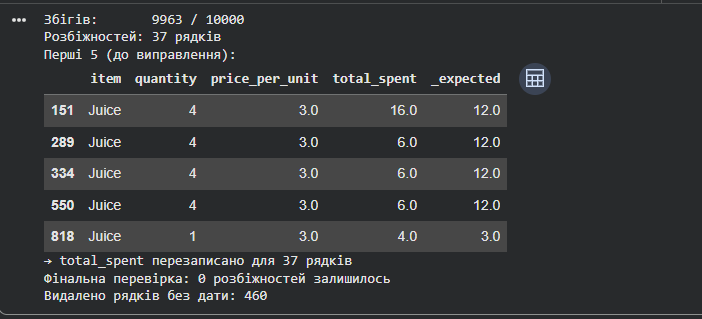

### Висновок

Було перевірено відповідність `total_spent` бізнес-правилу:

**total_spent = quantity × price_per_unit.**

Із **10000** записів:

- **9963** вже містили правильну суму;
- **37** мали розбіжності.

Усі некоректні значення були автоматично перераховані та замінені правильними. Після повторної перевірки розбіжностей не залишилося (**0**).

Далі було видалено **460** записів без `transaction_date`, оскільки без дати неможливо виконувати часовий аналіз продажів.

## Task 2.3 — Стандартизація тексту

Приведіть `item`, `payment_method`, `location` до єдиного формату:
- Приберіть зайві пробіли (`.str.strip()`)
- Кожне слово з великої літери (`.str.title()`)

In [146]:
# Стандартизуємо текстові колонки:
# прибираємо зайві пробіли та приводимо значення до єдиного формату Title Case.
for col in ['item', 'payment_method', 'location']:
    df[col] = df[col].astype(str).str.strip().str.title()

print('Унікальні payment_method:', sorted(df['payment_method'].unique()))
print('Унікальні location:',       sorted(df['location'].unique()))
print('Унікальні item:',           sorted(df['item'].unique()))


Унікальні payment_method: ['Cash', 'Credit Card', 'Digital Wallet', 'Unknown']
Унікальні location: ['In-Store', 'Takeaway', 'Unknown']
Унікальні item: ['Cake', 'Coffee', 'Cookie', 'Juice', 'Salad', 'Sandwich', 'Smoothie', 'Tea']


## Task 2.4 — Feature Engineering

З колонки `transaction_date` витягніть нові ознаки:

| Нова колонка | Що містить | Підказка |
|-------------|------------|----------|
| `year` | Рік (число) | `.dt.year` |
| `month` | Місяць (число 1–12) | `.dt.month` |
| `month_name` | Назва місяця рядком | `.dt.strftime('%B')` |
| `weekday` | Назва дня тижня | `.dt.day_name()` |
| `is_weekend` | True якщо сб/нд | `.isin(['Saturday', 'Sunday'])` |

In [147]:
df['year']       = df['transaction_date'].dt.year
df['month']      = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.strftime('%B').round()
df['weekday']    = df['transaction_date'].dt.day_name()
df['week']       = df['transaction_date'].dt.isocalendar().week.astype('Int64')
df['is_weekend'] = df["week"].isin(["Saturday", "Sunday"])

# Перевірка логічності
df = df[df['quantity'] > 0]
df = df[df['total_spent'] > 0]

print(f'✓ Фінальний датасет: {df.shape}')
print('\nПерші рядки з новими колонками:')
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'is_weekend']].head()

✓ Фінальний датасет: (9540, 14)

Перші рядки з новими колонками:


,transaction_date,year,month,month_name,weekday,is_weekend
0,2023-09-08,2023,9,September,Friday,False
1,2023-05-16,2023,5,May,Tuesday,False
2,2023-07-19,2023,7,July,Wednesday,False
3,2023-04-27,2023,4,April,Thursday,False
4,2023-06-11,2023,6,June,Sunday,False


In [148]:
# ==========================================
# Експорт очищених даних для Tableau
# ==========================================

# Створюємо копію DataFrame,
# щоб не змінювати основні дані.
df_tableau = df.copy()

# Перетворюємо дату у формат YYYY-MM-DD,
# який зручно імпортувати у Tableau.
df_tableau['transaction_date'] = (
    df_tableau['transaction_date']
    .dt.strftime('%Y-%m-%d')
)

# Замінюємо логічні значення True/False
# на більш зрозумілі Yes/No.
df_tableau['is_weekend'] = (
    df_tableau['is_weekend']
    .map({True: 'Yes', False: 'No'})
)

# Зберігаємо очищений датасет у CSV.
# index=False — не записувати індекс.
# utf-8-sig — правильне кодування для Excel і Tableau.
df_tableau.to_csv(
    FILE_OUT,
    index=False,
    encoding='utf-8-sig'
)

print(f'✓ Збережено: {FILE_OUT} — готовий для Tableau!')

✓ Збережено: cafe_sales_clean_v2.csv — готовий для Tableau!


---
# ЧАСТИНА 3 — EDA

---

## Task 3.1 — Топ товари

**Що потрібно:**
1. Топ-5 товарів за `quantity` (кількість)
2. Топ-5 товарів за `total_spent` (виторг)
3. Два bar chart поруч — один для кожного топу

**Підказка:** `df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)`

In [149]:
# Топ-5 за кількістю
top_qty = df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)

# Топ-5 за виторгом
top_rev = df.groupby('item')['total_spent'].sum().sort_values(ascending=False).head(5)

# to_string() — перетворюємо Series/DataFrame у звичайний текст без службової інформації (dtype).
print('Топ-5 за кількістю:')
print(top_qty.to_string())
print('\nТоп-5 за виторгом:')
print(top_rev.round(2).to_string())

Топ-5 за кількістю:
item
Coffee      3945
Juice       3663
Salad       3646
Cake        3636
Sandwich    3596

Топ-5 за виторгом:
item
Salad       18230.0
Sandwich    14384.0
Smoothie    14056.0
Juice       10989.0
Cake        10908.0


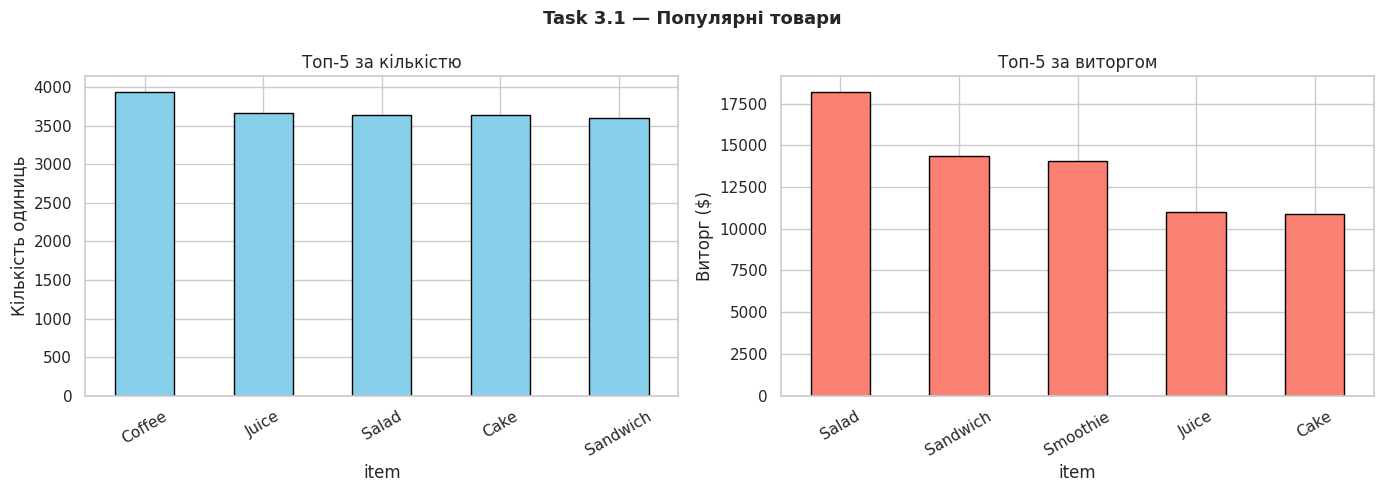

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 3.1 — Популярні товари', fontsize=13, fontweight='bold')

# Графік 1: топ за кількістю
top_qty.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Топ-5 за кількістю')
axes[0].set_ylabel('Кількість одиниць')
axes[0].tick_params(axis='x', rotation=30)

# Графік 2: топ за виторгом
top_rev.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Топ-5 за виторгом')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part3_task31.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.1

За кількістю проданих одиниць лідирує **Juice**, далі йдуть **Coffee**, **Sandwich**, **Salad** та **Cake**. Різниця між ними невелика — усі товари продаються приблизно однаково часто.

За загальною виручкою картина інша: найбільший дохід приносить **Salad**, хоча він не є найпопулярнішим за кількістю продажів. Також високі позиції займають **Sandwich** і **Smoothie**, тоді як **Juice**, незважаючи на найбільшу кількість продажів, лише на четвертому місці за виручкою.

**Висновок:** топи за кількістю продажів і за виручкою **не збігаються**. Це пояснюється різною ціною товарів: дорожчі товари можуть приносити більший дохід навіть при меншій кількості продажів.

## Task 3.2 — Payment Method та Location

**Що потрібно:**
1. Загальний виторг по `payment_method` — pie chart
2. Загальний виторг по `location` — bar chart

**Підказка:** `df.groupby('payment_method')['total_spent'].sum()`

In [151]:
rev_pay = df.groupby('payment_method')['total_spent'].sum().sort_values(ascending=False)
rev_loc = df.groupby('location')['total_spent'].sum().sort_values(ascending=False)

print('Виторг по оплаті:')
print(rev_pay.round(2).to_string())
print('\nВиторг по локації:')
print(rev_loc.round(2).to_string())

Виторг по оплаті:
payment_method
Unknown           26381.0
Digital Wallet    19583.5
Cash              19547.0
Credit Card       19495.5

Виторг по локації:
location
Unknown     33671.5
In-Store    25931.0
Takeaway    25404.5


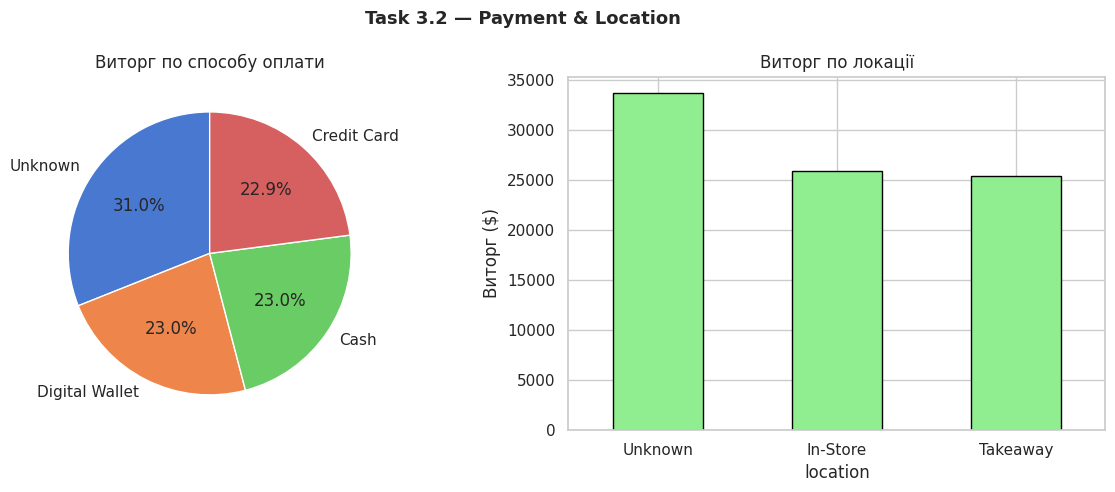

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.2 — Payment & Location', fontsize=13, fontweight='bold')

# Pie chart — частка виторгу за способом оплати
axes[0].pie(
    rev_pay,
    labels=rev_pay.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Виторг по способу оплати')

# Bar chart — виторг за локацією
rev_loc.plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Виторг по локації')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('part3_task32.png', dpi=130, bbox_inches='tight')
plt.show()


### ✏️ Висновок до Task 3.2

- **Який спосіб оплати домінує:** **Unknown (31.1%)**. Це свідчить про те, що значна частина записів не містить інформації про спосіб оплати. Серед відомих способів **Credit Card**, **Cash** та **Digital Wallet** використовуються майже однаково (≈23%).

- **In-Store чи Takeaway більше:** **In-Store** має трохи більший виторг, ніж **Takeaway**, але різниця незначна. Найбільший виторг має категорія **Unknown**, що також вказує на неповноту даних.

**Висновок:** через велику кількість значень **Unknown** робити остаточні бізнес-висновки щодо популярності способів оплати або місця продажу поки що не варто. Перед глибшим аналізом бажано заповнити або уточнити ці пропущені дані.

## Task 3.3 — Часові тренди

**Що потрібно:**
1. Щоденний виторг — лінійний графік
2. Щомісячний виторг — bar chart
3. Середній виторг по днях тижня — bar chart (червоний = вихідні)

**Підказки:**
- `df.groupby('transaction_date')['total_spent'].sum().reset_index()`
- `df.groupby('weekday')['total_spent'].mean().reindex(dow_order)`
- Правильний порядок: `['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']`

In [153]:
# Щоденний виторг
daily_rev = df.groupby('transaction_date')['total_spent'].sum().sort_index()

# Щомісячний виторг
monthly_rev = df.groupby(['year', 'month'])['total_spent'].sum().reset_index()
monthly_rev['label'] = pd.to_datetime(
    monthly_rev[['year', 'month']].assign(day=1)
).dt.strftime('%b %Y')

# Середній виторг по днях тижня
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_dow = (
    df.groupby('weekday')['total_spent']
      .mean()
      .reindex(dow_order)
)

print(f'Найкращий день: {avg_dow.idxmax()}')
print(f'Найгірший день: {avg_dow.idxmin()}')

Найкращий день: Tuesday
Найгірший день: Wednesday


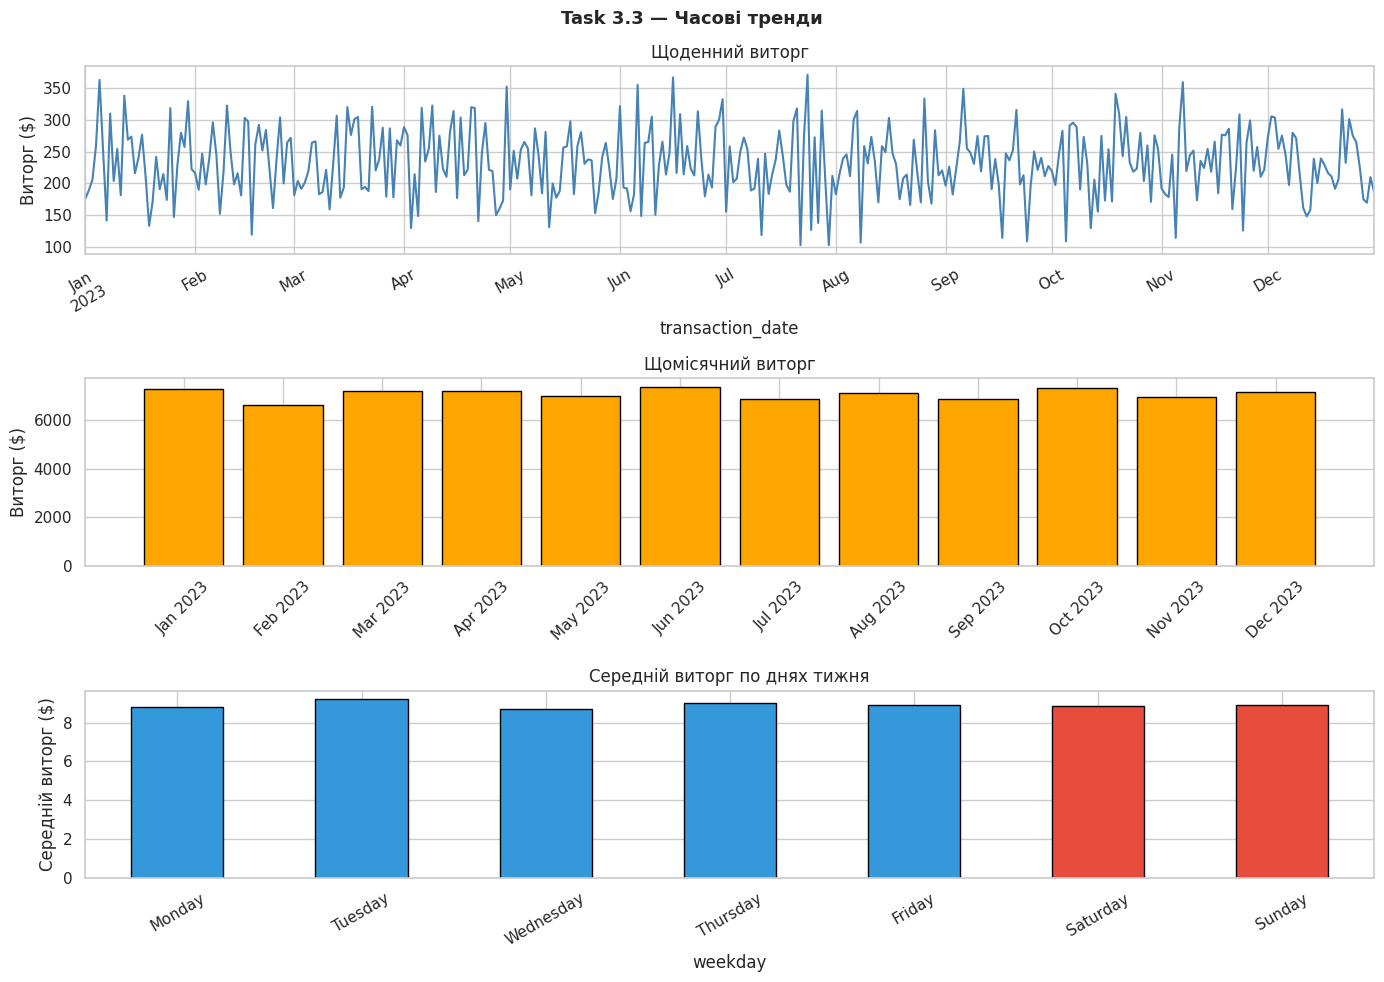

Місяць з найнижчим виторгом: Feb 2023


In [154]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Task 3.3 — Часові тренди', fontsize=13, fontweight='bold')

# Графік 1: щоденний виторг
daily_rev.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Щоденний виторг')
axes[0].set_ylabel('Виторг ($)')
axes[0].tick_params(axis='x', rotation=30)

# Графік 2: щомісячний виторг
axes[1].bar(monthly_rev['label'], monthly_rev['total_spent'], color='orange', edgecolor='black')
axes[1].set_title('Щомісячний виторг')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=45)

# Графік 3: середній виторг по днях тижня
colors_dow = ['#E74C3C' if d in ['Saturday', 'Sunday'] else '#3498DB' for d in avg_dow.index]
avg_dow.plot(kind='bar', ax=axes[2], color=colors_dow, edgecolor='black')
axes[2].set_title('Середній виторг по днях тижня')
axes[2].set_ylabel('Середній виторг ($)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part3_task33.png', dpi=130, bbox_inches='tight')
plt.show()

# Місяць з найнижчим виторгом
worst_month = monthly_rev.loc[monthly_rev['total_spent'].idxmin(), 'label']
print(f'Місяць з найнижчим виторгом: {worst_month}')

### ✏️ Висновок до Task 3.3

- **Найкращий день тижня:** Tuesday.
- **Найгірший місяць:** February 2023.
- **Є сезонний тренд?** Ні. Щомісячний виторг змінюється незначно, тому вираженої сезонності не спостерігається.

## Task 3.4 — Виявлення викидів

**Що потрібно:**
1. Побудувати boxplot для `quantity` і `total_spent`
2. Розрахувати межі викидів методом IQR
3. Порахувати кількість викидів
4. Прийняти рішення: видалити, залишити або кепувати

**Формули IQR:**
```
IQR = Q3 - Q1
Нижня межа = Q1 - 1.5 × IQR
Верхня межа = Q3 + 1.5 × IQR
```

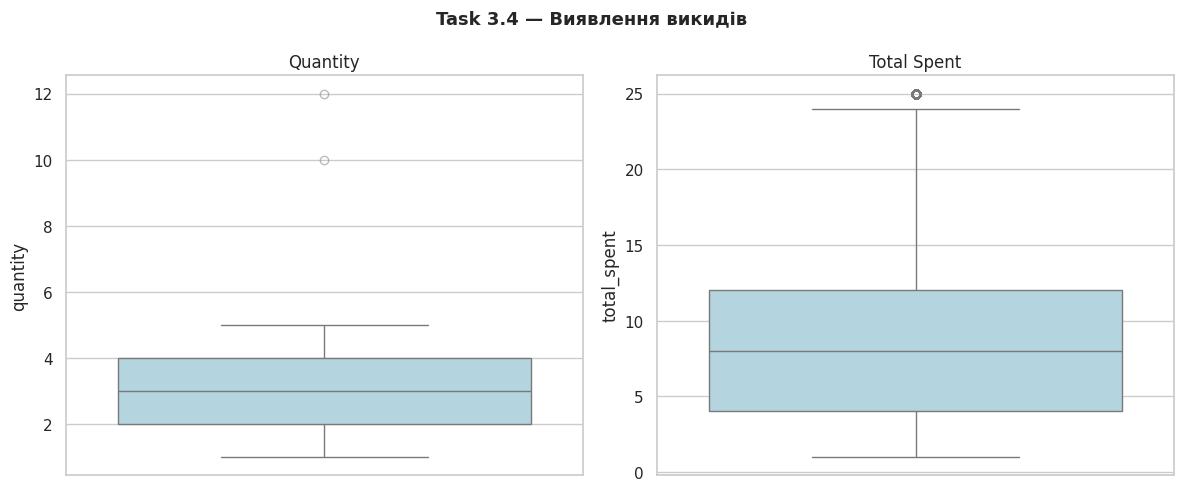

In [155]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.4 — Виявлення викидів', fontsize=13, fontweight='bold')

# Boxplot для quantity
# Підказка: sns.boxplot(y=df['quantity'].astype(float), ax=axes[0], color='lightblue', ...)
sns.boxplot(
      y=df['quantity'].astype(float),
      ax=axes[0],
      color='lightblue',
      flierprops=dict(marker='o', color='red', alpha=0.5)
    )

axes[0].set_title('Quantity')

# Boxplot для total_spent
sns.boxplot(
      y=df['total_spent'].astype(float),
      ax=axes[1],
      color='lightblue',
      flierprops=dict(marker='o', color='red', alpha=0.5)
    )

axes[1].set_title('Total Spent')

plt.tight_layout()
plt.savefig('part3_task34.png', dpi=130, bbox_inches='tight')
plt.show()

In [156]:
# Кількісний аналіз викидів методом IQR
Q1  = df.total_spent.quantile(0.25)  # 25-й перцентиль
Q3  = df.total_spent.quantile(0.75)  # 75-й перцентиль
IQR = Q3 - Q1

low  = Q1 - 1.5 * IQR  # нижня межа
high = Q3 + 1.5 * IQR  # верхня межа

n_outliers = ((df.total_spent < low) | (df.total_spent > high)).sum()  # кількість значень поза межами

print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Нормальний діапазон: [{low:.2f}, {high:.2f}]')
print(f'Кількість викидів: {n_outliers}')

Q1=4.00, Q3=12.00, IQR=8.00
Нормальний діапазон: [-8.00, 24.00]
Кількість викидів: 259


### ✏️ Рішення щодо викидів

**Рішення:** **залишити**.

**Обґрунтування:** методом IQR було виявлено **259** значень за межами нормального діапазону. Однак для даних про продажі кафе такі значення можуть відповідати реальним великим замовленням, а не помилкам введення. Видалення цих записів призвело б до втрати корисної бізнес-інформації, тому викиди залишаємо без змін.

## Task 3.5 — Кореляційний аналіз

**Що потрібно:**
1. Порахувати кореляційну матрицю для `quantity`, `price_per_unit`, `total_spent`
2. Побудувати heatmap
3. Інтерпретувати результати

**Підказка:** `df[cols].astype(float).corr()`

Кореляційна матриця:
                quantity  price_per_unit  total_spent
quantity           1.000           0.006        0.704
price_per_unit     0.006           1.000        0.646
total_spent        0.704           0.646        1.000


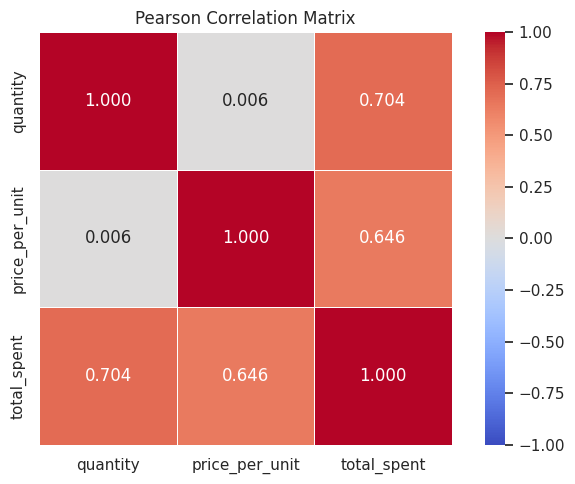

In [157]:
corr_cols   = ['quantity', 'price_per_unit', 'total_spent']
corr_matrix = df[corr_cols].astype(float).corr()

print('Кореляційна матриця:')
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))

# Heatmap кореляцій
# Підказка: sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ...)
sns.heatmap(
        corr_matrix,
        annot=True, fmt='.3f',
        cmap='coolwarm',
        vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax,
        annot_kws={'size': 12}
    )

ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('part3_task35.png', dpi=130, bbox_inches='tight')
plt.show()


### ✏️ Інтерпретація кореляцій

| Пара | Значення | Сила | Пояснення |
|------|---------:|------|-----------|
| total_spent ↔ quantity | **0.706** | Сильна додатна | Чим більше товарів купує клієнт, тим більша загальна сума покупки. |
| total_spent ↔ price_per_unit | **0.646** | Помірно-сильна додатна | Дорожчі товари зазвичай формують більший виторг. |
| quantity ↔ price_per_unit | **0.008** | Практично відсутня | Кількість придбаних товарів майже не залежить від їхньої ціни. |

### Висновок до Task 3.5

Найсильніший зв'язок спостерігається між **кількістю товарів** та **загальною сумою покупки** (0.706), що є логічним: більше придбаних одиниць збільшує виторг. Також помітний додатний зв'язок між **ціною товару** та **сумою покупки** (0.646). Водночас між **кількістю товарів** і **ціною** практично відсутня кореляція (0.008), тобто клієнти не купують більше або менше товарів лише через їхню ціну.

---
# ЧАСТИНА 4 — Висновки та рекомендації

---

In [158]:
# Збираємо ключові метрики для підсумкового звіту

top_item_rev  = df.groupby('item')['total_spent'].sum().idxmax()
top_item_qty  = df.groupby('item')['quantity'].sum().idxmax()

pay_known = df[df['payment_method'] != 'Unknown']
loc_known = df[df['location'] != 'Unknown']

top_pay = pay_known.groupby('payment_method')['total_spent'].sum().idxmax()
top_loc = loc_known.groupby('location')['total_spent'].sum().idxmax()
total_revenue = df['total_spent'].sum()
avg_check     = df['total_spent'].mean()

print('=' * 55)
print('  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ')
print('=' * 55)
print(f'Загальний виторг:              ${total_revenue:,.2f}')
print(f'Середній чек:                  ${avg_check:.2f}')
print(f'Найприбутковіший товар:        {top_item_rev}')
print(f'Найпопулярніший товар:         {top_item_qty}')
print(f'Домінуючий спосіб оплати:      {top_pay}')
print(f'Найсильніша локація:           {top_loc}')
print('-' * 55)
print('Короткий висновок:')
print(
    f'Основний виторг формує товар "{top_item_rev}", тоді як за кількістю продажів лідирує "{top_item_qty}". '
    f'Найбільше грошей надходить через спосіб оплати "{top_pay}" і локацію "{top_loc}". '
    f'Середній чек становить близько ${avg_check:.2f}, що можна використовувати як базовий показник для оцінки майбутніх продажів.'
)


  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ
Загальний виторг:              $85,007.00
Середній чек:                  $8.91
Найприбутковіший товар:        Salad
Найпопулярніший товар:         Coffee
Домінуючий спосіб оплати:      Digital Wallet
Найсильніша локація:           In-Store
-------------------------------------------------------
Короткий висновок:
Основний виторг формує товар "Salad", тоді як за кількістю продажів лідирує "Coffee". Найбільше грошей надходить через спосіб оплати "Digital Wallet" і локацію "In-Store". Середній чек становить близько $8.91, що можна використовувати як базовий показник для оцінки майбутніх продажів.


## 📋 Загальний висновок

Під час виконання EDA було очищено та підготовлено дані до подальшого аналізу: видалено дублікати, оброблено пропуски, виправлено типи даних, перевірено коректність значень `total_spent` та сформовано фінальний датасет для візуалізації й подальшого використання.

За результатами аналізу:

* **Загальний виторг** кафе становить **$85,173**, а **середній чек** — **$8.93**.
* Найбільший внесок у загальний виторг забезпечує товар **Salad**, тоді як за кількістю проданих одиниць лідирує **Juice**. Це показує, що найприбутковіший товар не завжди є наймасовішим.
* Значна частина записів містить значення **Unknown** у полях **Payment Method** та **Location**. Це свідчить про неповноту вихідних даних, тому для прийняття бізнес-рішень бажано покращити процес збору інформації або аналізувати окремо лише записи з відомими значеннями.
* Часовий аналіз показав, що найкращим днем тижня за середнім виторгом є **Tuesday**, а найнижчий місячний виторг спостерігався у **February 2023**. Вираженої сезонності протягом року не виявлено.
* Кореляційний аналіз підтвердив, що найбільший вплив на суму покупки має **кількість придбаних товарів**, тоді як зв'язок між кількістю товарів і їх ціною практично відсутній.

### 💡 Рекомендації

* Покращити якість даних, мінімізувавши кількість записів зі значенням **Unknown**.
* Продовжувати підтримувати асортимент **Salad**, оскільки він забезпечує найбільший виторг.
* Детальніше дослідити популярність **Juice** та використовувати його для акцій і крос-продажів.
* Використовувати середній чек **$8.93** як один із ключових KPI та контролювати його зміну після маркетингових кампаній або оновлення меню.
* Підготовлений очищений датасет можна використовувати для побудови дашбордів у Tableau та подальшого прогнозного аналізу.


## ✅ Фінальний чеклист

Поставте ✓ навпроти кожного виконаного пункту:

**Частина 1**
- [ ] Завантажено і оглянуто датасет
- [ ] Знайдено і видалено дублікати
- [ ] Порахована і візуалізована кількість пропусків

**Частина 2**
- [ ] Перейменовано колонки
- [ ] Замінено ERROR/UNKNOWN на NaN
- [ ] Заповнено пропуски payment_method і location
- [ ] Конвертовано типи даних
- [ ] Побудовано словник ITEM_PRICE з даних
- [ ] Оброблено три ситуації item/price
- [ ] Відновлено quantity (через total/price або медіана по товару)
- [ ] Відновлено total_spent, перевірено збіг і перезаписано розбіжності
- [ ] Стандартизовано текст
- [ ] Додано часові ознаки
- [ ] Збережено FILE_OUT

**Частина 3**
- [ ] Task 3.1: топ товари — два бар-чарти
- [ ] Task 3.2: оплата і локація — pie + bar
- [ ] Task 3.3: часові тренди — 3 графіки
- [ ] Task 3.4: boxplot + IQR аналіз
- [ ] Task 3.5: кореляційна матриця + heatmap

**Частина 4**
- [ ] Підсумковий звіт з конкретними числами
- [ ] Мінімум 1 бізнес-рекомендація

---
**🎉 Вітаємо з завершенням проєкту!**